In [1]:
import ee
import pandas as pd
import numpy as np
import random


In [2]:
# service_account = 'localpythonscripts@ut-gee-ugs-bsf-dev.iam.gserviceaccount.com'
# credentials = ee.ServiceAccountCredentials(service_account, 'C:\\Users\\mradwin\\ut-gee-ugs-bsf-dev-53dcc5d729e0.json')
# ee.Initialize(credentials=credentials)

service_account = 'ubm-swb@ut-gee-ugs-uswb-dev.iam.gserviceaccount.com'
credentials = ee.ServiceAccountCredentials(service_account, 'C:\\Users\\mradwin\\ut-gee-ugs-uswb-dev-77ffc61a8874.json')
ee.Initialize(credentials=credentials)

In [3]:


def run_oat_sensitivity(df, base_st, base_por, base_fc, base_geok, basin_area_m2):
    """
    Runs a One-At-A-Time (OAT) parameter sensitivity simulation with custom scaling ranges.
    """
    precip_ts_base = df['precip_and_snowmelt_input'].values
    irr_ts = df['irrigation'].values
    aet_ts_base = df['AET'].values
    
    # Define custom perturbation values for each parameter
    # For Porosity, we define absolute values. For others, we define multipliers.
    test_ranges = {
        'Precipitation': np.round(np.arange(0.5, 1.6, 0.1), 1),       # 0.5x to 1.5x
        'AET': np.round(np.arange(0.5, 1.6, 0.1), 1),                 # 0.5x to 1.5x
        'Soil_Thickness': np.array([0.2, 0.5, 0.8, 1.0, 2.0, 3.0, 4.0, 5.0]), # 0.2x to 5.0x
        'Soil_Porosity': np.array([0.20, 0.30, 0.40, base_por, 0.60, 0.70, 0.80]), # Absolute ranges
        'Field_Capacity': np.round(np.arange(0.5, 1.6, 0.1), 1),      # 0.5x to 1.5x
        'Geo_K': np.array([0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]) # Orders of magnitude
    }
    
    results = []
    
    for param_name, test_values in test_ranges.items():
        for val in test_values:
            
            # 1. Reset all parameters to base defaults
            sim_precip_ts = precip_ts_base
            sim_aet_ts = aet_ts_base
            sim_st = base_st
            sim_por = base_por
            sim_fc = base_fc
            sim_geok = base_geok
            
            # Calculate % change for elasticity tracking
            # (If it's porosity, val is absolute; otherwise val is a multiplier)
            if param_name == 'Soil_Porosity':
                input_pct_change = ((val - base_por) / base_por) * 100
            else:
                input_pct_change = (val - 1.0) * 100
                
            # 2. Apply the perturbation to the active parameter ONLY
            if param_name == 'Precipitation': sim_precip_ts = precip_ts_base * val
            elif param_name == 'AET': sim_aet_ts = aet_ts_base * val
            elif param_name == 'Soil_Thickness': sim_st = base_st * val
            elif param_name == 'Soil_Porosity': sim_por = val # Absolute replacement
            elif param_name == 'Field_Capacity': sim_fc = base_fc * val
            elif param_name == 'Geo_K': sim_geok = base_geok * val
            
            # Physical Reality Check: FC cannot exceed Max Soil Moisture
            sim_max_soil_moisture = sim_st * sim_por
            if sim_fc > sim_max_soil_moisture:
                sim_fc = sim_max_soil_moisture
            
            soil_water_prev = sim_fc 
            
            sim_total_runoff = 0
            sim_total_recharge = 0
            sim_sat_pct_list = []
            
            # 3. UBM Step Function Logic
            for t in range(len(df)):
                precip = sim_precip_ts[t]
                irr = irr_ts[t]
                aet = sim_aet_ts[t]
                
                aw_initial = precip + irr + soil_water_prev
                et_offset = min(aet, aw_initial)
                aw = aw_initial - et_offset
                
                if aw > sim_max_soil_moisture:
                    # SCENARIO 1: Saturation
                    aw_recharge = sim_max_soil_moisture - sim_fc
                    recharge = min(aw_recharge, sim_geok)
                    s_int = aw - recharge
                    runoff = max(s_int - sim_max_soil_moisture, 0)
                    soil_water = sim_max_soil_moisture if s_int > sim_max_soil_moisture else s_int
                    soil_water = max(0, soil_water) 
                    
                elif aw > sim_fc:
                    # SCENARIO 2: Gravity Drainage
                    aw_recharge = aw - sim_fc
                    recharge = min(aw_recharge, sim_geok)
                    runoff = 0
                    soil_water_raw = aw - recharge
                    gravity_zone_cap = sim_max_soil_moisture - sim_fc
                    
                    drain_is_guaranteed = sim_geok >= gravity_zone_cap
                    if drain_is_guaranteed:
                        soil_water = sim_fc
                    else:
                        soil_water = max(0, soil_water_raw) 
                        
                else:
                    # SCENARIO 3: Water Limited
                    recharge = 0
                    runoff = 0
                    soil_water = max(0, aw)
                    
                sat_pct = (soil_water / sim_max_soil_moisture) * 100
                sim_total_runoff += runoff
                sim_total_recharge += recharge
                sim_sat_pct_list.append(sat_pct)
                
                soil_water_prev = soil_water
                
            # Convert final depth totals (mm) to acre-feet
            runoff_af = ((sim_total_runoff / 1000) * basin_area_m2) / 1233.48
            recharge_af = ((sim_total_recharge / 1000) * basin_area_m2) / 1233.48
                
            # 4. Store Result
            results.append({
                'Parameter_Altered': param_name,
                'Input_Value_or_Multiplier': val,
                'Input_Change_Pct': round(input_pct_change, 2),
                'Total_Runoff_acft': runoff_af,
                'Total_Recharge_acft': recharge_af,
                'Mean_Soil_Saturation_Pct': np.mean(sim_sat_pct_list)
            })
            
    detailed_df = pd.DataFrame(results)
    
    # 5. Calculate Quantitative Sensitivity (Elasticity) Summary
    summary_data = []
    
    # Extract baseline outputs (where Input_Change_Pct == 0)
    base_mask = detailed_df['Input_Change_Pct'] == 0.0
    
    for param in test_ranges.keys():
        # Get baseline specifically for this parameter block
        base_row = detailed_df[(detailed_df['Parameter_Altered'] == param) & base_mask]
        if base_row.empty:
            continue
            
        base_runoff = base_row['Total_Runoff_acft'].iloc[0]
        base_recharge = base_row['Total_Recharge_acft'].iloc[0]
        base_sat = base_row['Mean_Soil_Saturation_Pct'].iloc[0]

        param_df = detailed_df[detailed_df['Parameter_Altered'] == param].copy()
        
        # Calculate % Change in Outputs
        x_pct = param_df['Input_Change_Pct'].values
        y_runoff_pct = np.where(base_runoff != 0, ((param_df['Total_Runoff_acft'] - base_runoff) / base_runoff) * 100, 0)
        y_recharge_pct = np.where(base_recharge != 0, ((param_df['Total_Recharge_acft'] - base_recharge) / base_recharge) * 100, 0)
        y_sat_pct = np.where(base_sat != 0, ((param_df['Mean_Soil_Saturation_Pct'] - base_sat) / base_sat) * 100, 0)
        
        # Calculate Elasticity using linear regression slope (degree 1)
        # Note: For Geo_K, standard linear elasticity will be heavily skewed by the massive X values, 
        # but it still provides a bulk directionality metric.
        slope_runoff = np.polyfit(x_pct, y_runoff_pct, 1)[0]
        slope_recharge = np.polyfit(x_pct, y_recharge_pct, 1)[0]
        slope_sat = np.polyfit(x_pct, y_sat_pct, 1)[0]
        
        summary_data.append({
            'Parameter': param,
            'Runoff_Elasticity': round(slope_runoff, 3),
            'Recharge_Elasticity': round(slope_recharge, 3),
            'Soil_Sat_Elasticity': round(slope_sat, 3)
        })
        
    sensitivity_summary_df = pd.DataFrame(summary_data)
    
    return sensitivity_summary_df, detailed_df

In [4]:
data_file = "C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\ubm_zonal_stats_boundary_type=HUC6_Basins_region_name=Weber_data.parquet"
df = pd.read_parquet(data_file)
print(df.head())

        Date  precip_and_snowmelt_input  irrigation         AET     Runoff  \
0 2005-01-01                  95.875923    0.000000    7.229075  11.606679   
1 2005-02-01                  72.303185    0.000000   16.788586   7.420249   
2 2005-03-01                 108.575439    0.000000   39.295258  13.862644   
3 2005-04-01                  83.992805    2.961791   71.136963   6.390600   
4 2005-05-01                 123.551216    7.700657  115.643936   8.796327   

    Recharge  Soil_Water_End_Of_Previous_Timestep  \
0  70.962761                           150.612732   
1  51.399734                           146.969131   
2  52.016216                           149.695038   
3  26.883911                           131.914352   
4  15.373899                           123.117538   

   Soil_Saturation_Percent_End_Of_Timestep  precip_and_snowmelt_input_m3  \
0                                66.636032                   617586304.0   
1                                64.300224                  

In [5]:
monte_carlo_run_summary, monte_carlo_run_df = run_oat_sensitivity(df, 458.87, 0.5096, 116.39, 15763, 6.43E9)

In [6]:
print(monte_carlo_run_summary)

        Parameter  Runoff_Elasticity  Recharge_Elasticity  Soil_Sat_Elasticity
0   Precipitation             30.542                1.588                0.782
1             AET             -2.186               -0.648               -0.578
2  Soil_Thickness            -29.584                0.172               -0.368
3   Soil_Porosity           -140.462                0.866               -1.230
4  Field_Capacity             25.727               -0.542                1.107
5           Geo_K             -0.015                0.000               -0.000


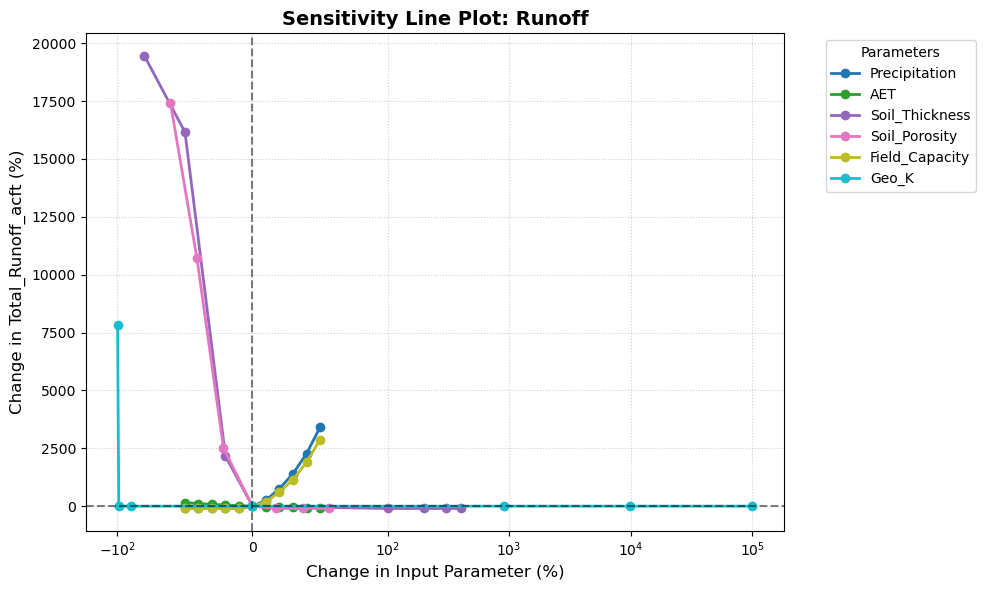

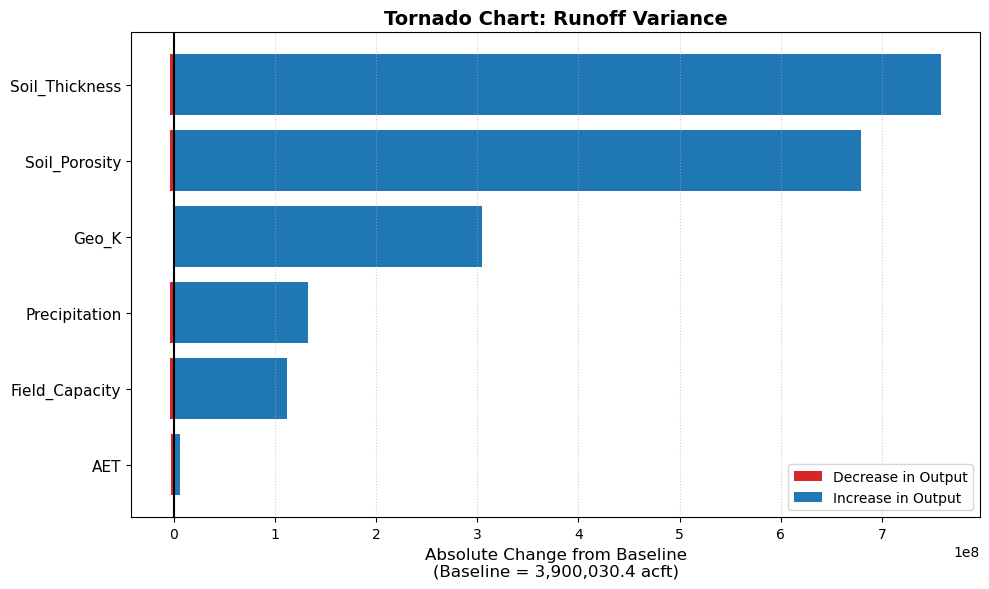

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_sensitivity_lines(detailed_df, output_col='Total_Runoff_acft', title="Sensitivity Line Plot: Runoff"):
    """
    Creates a line plot showing how % change in inputs affects the % change in the chosen output.
    """
    plt.figure(figsize=(10, 6))
    
    parameters = detailed_df['Parameter_Altered'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(parameters)))
    
    for i, param in enumerate(parameters):
        param_df = detailed_df[detailed_df['Parameter_Altered'] == param].copy()
        param_df = param_df.sort_values('Input_Change_Pct')
        
        # Safely find the baseline (where change is 0%)
        base_row = param_df[np.isclose(param_df['Input_Change_Pct'], 0.0)]
        if base_row.empty:
            continue
            
        base_val = base_row[output_col].iloc[0]
        
        # Calculate % Change in Output
        x = param_df['Input_Change_Pct'].values
        if base_val != 0:
            y = ((param_df[output_col] - base_val) / base_val) * 100
        else:
            y = np.zeros(len(x))
            
        plt.plot(x, y, marker='o', linewidth=2, label=param, color=colors[i])

    # Use a symmetrical log scale for X to handle Geo_K's massive outliers 
    # while keeping the -50 to +50 range readable
    plt.xscale('symlog', linthresh=100) 
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Change in Input Parameter (%)', fontsize=12)
    plt.ylabel(f'Change in {output_col} (%)', fontsize=12)
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend(title='Parameters', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_sensitivity_tornado(detailed_df, output_col='Total_Runoff_acft', title="Tornado Chart: Runoff Sensitivity Range"):
    """
    Creates a tornado chart showing the maximum positive and negative swing 
    from the baseline output for each parameter.
    """
    parameters = detailed_df['Parameter_Altered'].unique()
    
    # Store the swings for plotting
    tornado_data = []
    
    for param in parameters:
        param_df = detailed_df[detailed_df['Parameter_Altered'] == param]
        
        base_row = param_df[np.isclose(param_df['Input_Change_Pct'], 0.0)]
        if base_row.empty:
            continue
            
        base_val = base_row[output_col].iloc[0]
        min_val = param_df[output_col].min()
        max_val = param_df[output_col].max()
        
        # Calculate the delta from baseline
        neg_swing = min_val - base_val
        pos_swing = max_val - base_val
        total_variance = abs(max_val - min_val)
        
        tornado_data.append({
            'Parameter': param,
            'Negative_Swing': neg_swing,
            'Positive_Swing': pos_swing,
            'Total_Variance': total_variance,
            'Base_Value': base_val
        })
        
    tornado_df = pd.DataFrame(tornado_data)
    
    # Sort by total variance so the most sensitive parameters are at the top
    tornado_df = tornado_df.sort_values('Total_Variance', ascending=True)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    
    y_pos = np.arange(len(tornado_df))
    
    # Plot the negative and positive swings
    ax.barh(y_pos, tornado_df['Negative_Swing'], color='#d62728', align='center', label='Decrease in Output')
    ax.barh(y_pos, tornado_df['Positive_Swing'], color='#1f77b4', align='center', label='Increase in Output')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tornado_df['Parameter'], fontsize=11)
    ax.axvline(0, color='black', linewidth=1.5)
    
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Extract the common base value to show in the x-label (they should all be the same)
    common_base = tornado_df['Base_Value'].iloc[0] if not tornado_df.empty else 0
    plt.xlabel(f'Absolute Change from Baseline\n(Baseline = {common_base:,.1f} {output_col.split("_")[-1]})', fontsize=12)
    
    plt.grid(True, axis='x', linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# === HOW TO USE ===
# Run these using the 'detailed_df' generated from the previous simulation script.
# You can change the 'output_col' to look at Recharge or Soil Saturation instead.

plot_sensitivity_lines(monte_carlo_run_df, output_col='Total_Runoff_acft', title="Sensitivity Line Plot: Runoff")
plot_sensitivity_tornado(monte_carlo_run_df, output_col='Total_Runoff_acft', title="Tornado Chart: Runoff Variance")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def run_ubm_oat_sensitivity(df, base_st, base_por, base_fc, base_geok, basin_area_m2):
    """
    Runs a rigorous OAT sensitivity analysis. Standard parameters use -50% to +50%.
    Geo_K uses a log-symmetrical scale from 10^-4x to 10^4x centered exactly at 1.0x baseline.
    """
    precip_ts_base = df['precip_and_snowmelt_input'].values
    irr_ts = df['irrigation'].values
    aet_ts_base = df['AET'].values
    
    # 21 uniform steps to represent the variation space
    steps = np.linspace(-50, 50, 51)
    
    parameters = ['Precipitation', 'AET', 'Soil_Thickness', 'Soil_Porosity', 'Field_Capacity', 'Geo_K']
    results = []
    
    for param_name in parameters:
        for step in steps:
            # Reset defaults
            sim_precip_ts = precip_ts_base
            sim_aet_ts = aet_ts_base
            sim_st = base_st
            sim_por = base_por
            sim_fc = base_fc
            sim_geok = base_geok
            
            # Apply uniform linear multipliers (-50% to +50%)
            mult = 1.0 + (step / 100.0)
            
            if param_name == 'Precipitation':
                sim_precip_ts = precip_ts_base * mult
            elif param_name == 'AET':
                sim_aet_ts = aet_ts_base * mult
            elif param_name == 'Soil_Thickness': 
                sim_st = base_st * mult
            elif param_name == 'Soil_Porosity': 
                sim_por = base_por * mult
            elif param_name == 'Field_Capacity': 
                sim_fc = base_fc * mult
            elif param_name == 'Geo_K': 
                # PERFECTLY CENTERED LOG SCALE:
                log_min = -5.0  # <--- Change this to adjust the lower bound (currently 10^-4)
                log_max = 5.0   # <--- Change this to adjust the upper bound (currently 10^4)

                linear_fraction = (step - (-50.0)) / 100.0  
                log_val = log_min + linear_fraction * (log_max - log_min)
                sim_geok = base_geok * (10.0 ** log_val)
            
            # --- Physical Reality Check ---
            sim_max_soil_moisture = sim_st * sim_por
            if sim_fc > sim_max_soil_moisture:
                sim_fc = sim_max_soil_moisture
            
            # Initialize state (starts at field capacity)
            soil_water_prev = sim_fc 
            
            sim_total_runoff = 0
            
            # Timeseries Loop (The UBM Step Function Logic)
            for t in range(len(df)):
                precip = sim_precip_ts[t] if param_name == 'Precipitation' else precip_ts_base[t]
                irr = irr_ts[t]
                aet = sim_aet_ts[t] if param_name == 'AET' else aet_ts_base[t]
                
                aw_initial = precip + irr + soil_water_prev
                et_offset = min(aet, aw_initial)
                aw = aw_initial - et_offset
                
                if aw > sim_max_soil_moisture:
                    # SCENARIO 1: Saturation
                    aw_recharge = sim_max_soil_moisture - sim_fc
                    recharge = min(aw_recharge, sim_geok)
                    s_int = aw - recharge
                    runoff = max(s_int - sim_max_soil_moisture, 0)
                    soil_water = sim_max_soil_moisture if s_int > sim_max_soil_moisture else s_int
                elif aw > sim_fc:
                    # SCENARIO 2: Gravity Drainage
                    aw_recharge = aw - sim_fc
                    recharge = min(aw_recharge, sim_geok)
                    runoff = 0
                    soil_water_raw = aw - recharge
                    if sim_geok >= (sim_max_soil_moisture - sim_fc):
                        soil_water = sim_fc
                    else:
                        soil_water = max(0, soil_water_raw)
                else:
                    # SCENARIO 3: Water Limited
                    runoff = 0
                    soil_water = max(0, aw)
                    
                sim_total_runoff += runoff
                soil_water_prev = soil_water
                
            runoff_af = ((sim_total_runoff / 1000) * basin_area_m2) / 1233.48
            
            results.append({
                'Parameter_Altered': param_name,
                'Input_Deviation_Pct': step, 
                'Total_Runoff_acft': runoff_af
            })
            
    return pd.DataFrame(results)

def plot_fixed_visualizations(detailed_df, variable='Runoff'):
    """
    Plots sensitivity outputs cleanly with a standardized baseline multiplier Y-axis.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    parameters = detailed_df['Parameter_Altered'].unique()
    
    base_val = detailed_df[(detailed_df['Input_Deviation_Pct'] == 0.0)][f'Total_{variable}_acft'].iloc[0]
    
    # --- 1. LINE PLOT ---
    ax1 = axes[0]
    for param in parameters:
        param_df = detailed_df[detailed_df['Parameter_Altered'] == param].sort_values('Input_Deviation_Pct')
        y_multiplier = param_df[f'Total_{variable}_acft'] / base_val
        
        label_name = param if param != 'Geo_K' else 'Geo_K (Scaled by 10^-5 to 10^5)'
        ax1.plot(param_df['Input_Deviation_Pct'], y_multiplier, marker='o', linewidth=2, markersize=0, label=label_name)
        
    ax1.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Baseline Model')
    ax1.axvline(0.0, color='black', linestyle='--', alpha=0.5)
    
    ax1.set_yscale('log')
    ax1.set_title('Sensitivity Analysis', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Parameter Modification Extent (-50% to +50%)', fontsize=11)
    ax1.set_ylabel('Runoff Output (Multiplier of Baseline Value)', fontsize=11)
    ax1.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax1.set_xlim(-50, 50)
    ax1.grid(True, which='both', linestyle=':', alpha=0.5)
    ax1.legend(loc='lower left', fontsize=8, frameon=False)
    
    # --- 2. TORNADO CHART ---
    ax2 = axes[1]
    summary_data = []
    
    for param in parameters:
        param_df = detailed_df[detailed_df['Parameter_Altered'] == param]
        max_out = param_df[f'Total_{variable}_acft'].max()
        min_out = param_df[f'Total_{variable}_acft'].min()
        
        summary_data.append({
            'Parameter': param,
            'Min_Deviation_Pct': ((min_out - base_val) / base_val) * 100,
            'Max_Deviation_Pct': ((max_out - base_val) / base_val) * 100,
            'Total_Span': abs(((max_out - base_val) / base_val) * 100 - ((min_out - base_val) / base_val) * 100)
        })
        
    tdf = pd.DataFrame(summary_data).sort_values('Total_Span', ascending=True)
    y_pos = np.arange(len(tdf))
    
    ax2.barh(y_pos, tdf['Max_Deviation_Pct'] - tdf['Min_Deviation_Pct'], left=tdf['Min_Deviation_Pct'], 
             color='#1f77b4', edgecolor='black', height=0.5)
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(tdf['Parameter'], fontsize=11)
    ax2.axvline(0, color='red', linestyle='-', linewidth=1.5, label='Baseline Model')
    ax2.set_xscale('symlog', linthresh=10)
    
    ax2.set_title(f'Tornado Chart: Relative {variable} Impact Width', fontsize=12, fontweight='bold')
    ax2.set_xlabel(f'Potential Shift in {variable} Output (%)\n Negative Values Correspond to Increases in Each Variable\n Geo_K Range is 10^-5 to 10^5 - The Rest Span -50% to +50%', fontsize=11)
    ax2.set_xlim(-10**3, 10**5)
    ax2.grid(True, which='both', axis='x', linestyle=':', alpha=0.5)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

In [53]:
print(10**5 / 50)

2000.0


In [58]:
monte_carlo_run_df = run_ubm_oat_sensitivity(df, 458.87, 0.5096, 116.39, 15763, 6.43E9)
print(monte_carlo_run_df.head())

  Parameter_Altered  Input_Deviation_Pct  Total_Runoff_acft
0     Precipitation                -50.0                0.0
1     Precipitation                -48.0                0.0
2     Precipitation                -46.0                0.0
3     Precipitation                -44.0                0.0
4     Precipitation                -42.0                0.0


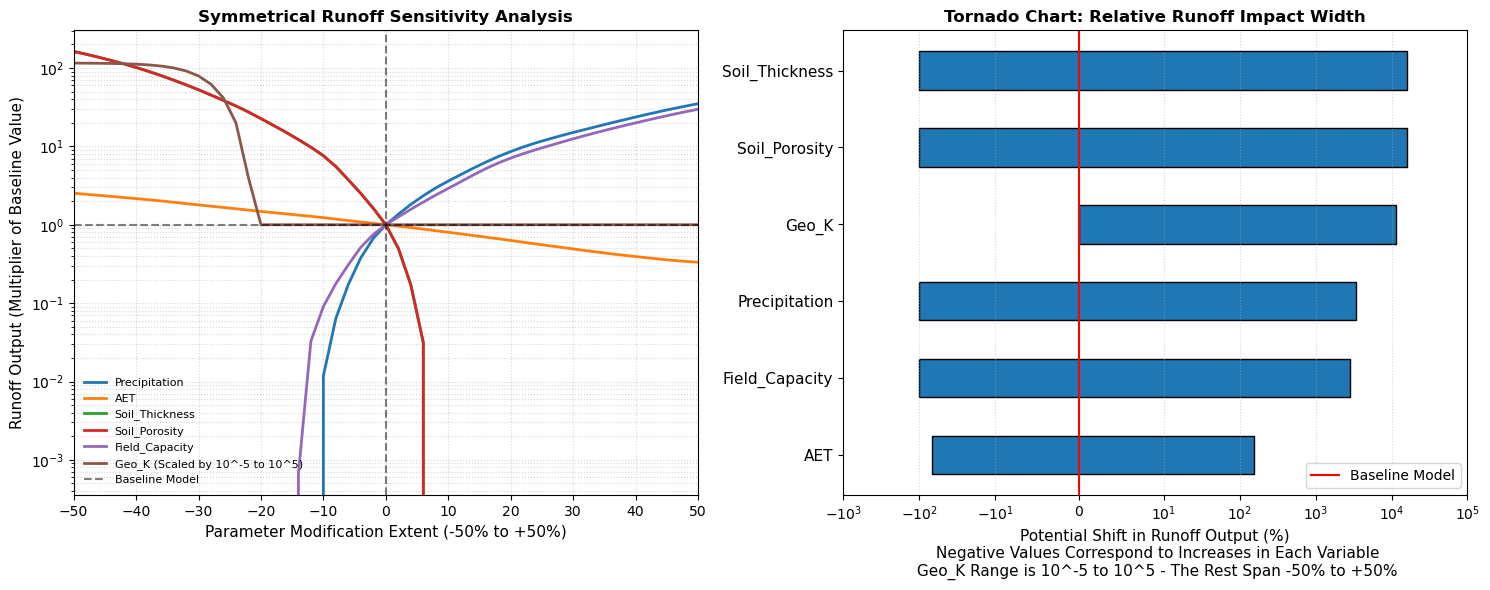

In [57]:
plot_fixed_visualizations(monte_carlo_run_df)

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def run_ubm_oat_sensitivity(df, base_st, base_por, base_fc, base_geok, basin_area_m2):
    """
    Runs a rigorous OAT sensitivity analysis tracking Runoff, Recharge, and Soil Saturation.
    Standard parameters use -50% to +50%.
    Geo_K uses a log-symmetrical scale from 10^-4x to 10^4x centered exactly at 1.0x baseline.
    """
    precip_ts_base = df['precip_and_snowmelt_input'].values
    irr_ts = df['irrigation'].values
    aet_ts_base = df['AET'].values
    
    # 21 uniform steps to represent the variation space
    steps = np.linspace(-50, 50, 21)
    
    parameters = ['Precipitation', 'AET', 'Soil_Thickness', 'Soil_Porosity', 'Field_Capacity', 'Geo_K']
    results = []
    
    for param_name in parameters:
        for step in steps:
            # Reset defaults
            sim_precip_ts = precip_ts_base
            sim_aet_ts = aet_ts_base
            sim_st = base_st
            sim_por = base_por
            sim_fc = base_fc
            sim_geok = base_geok
            
            # Apply uniform linear multipliers (-50% to +50%)
            mult = 1.0 + (step / 100.0)
            
            if param_name == 'Precipitation':
                sim_precip_ts = precip_ts_base * mult
            elif param_name == 'AET':
                sim_aet_ts = aet_ts_base * mult
            elif param_name == 'Soil_Thickness': 
                sim_st = base_st * mult
            elif param_name == 'Soil_Porosity': 
                sim_por = base_por * mult
            elif param_name == 'Field_Capacity': 
                sim_fc = base_fc * mult
            elif param_name == 'Geo_K': 
                # PERFECTLY CENTERED LOG SCALE: Exp -4..0..4
                log_exponent = (step / 50.0) * 4.0
                sim_geok = base_geok * (10.0 ** log_exponent)
            
            # --- Physical Reality Check ---
            sim_max_soil_moisture = sim_st * sim_por
            if sim_fc > sim_max_soil_moisture:
                sim_fc = sim_max_soil_moisture
            
            # Initialize state (starts at field capacity)
            soil_water_prev = sim_fc 
            
            sim_total_runoff = 0
            sim_total_recharge = 0
            sim_sat_pct_list = []
            
            # Timeseries Loop (The UBM Step Function Logic)
            for t in range(len(df)):
                precip = sim_precip_ts[t] if param_name == 'Precipitation' else precip_ts_base[t]
                irr = irr_ts[t]
                aet = sim_aet_ts[t] if param_name == 'AET' else aet_ts_base[t]
                
                aw_initial = precip + irr + soil_water_prev
                et_offset = min(aet, aw_initial)
                aw = aw_initial - et_offset
                
                if aw > sim_max_soil_moisture:
                    # SCENARIO 1: Saturation
                    aw_recharge = sim_max_soil_moisture - sim_fc
                    recharge = min(aw_recharge, sim_geok)
                    s_int = aw - recharge
                    runoff = max(s_int - sim_max_soil_moisture, 0)
                    soil_water = sim_max_soil_moisture if s_int > sim_max_soil_moisture else s_int
                elif aw > sim_fc:
                    # SCENARIO 2: Gravity Drainage
                    aw_recharge = aw - sim_fc
                    recharge = min(aw_recharge, sim_geok)
                    runoff = 0
                    soil_water_raw = aw - recharge
                    if sim_geok >= (sim_max_soil_moisture - sim_fc):
                        soil_water = sim_fc
                    else:
                        soil_water = max(0, soil_water_raw)
                else:
                    # SCENARIO 3: Water Limited
                    recharge = 0
                    runoff = 0
                    soil_water = max(0, aw)
                    
                sat_pct = (soil_water / sim_max_soil_moisture) * 100
                sim_total_runoff += runoff
                sim_total_recharge += recharge
                sim_sat_pct_list.append(sat_pct)
                
                soil_water_prev = soil_water
                
            # Convert values to depth/volumes
            runoff_af = ((sim_total_runoff / 1000) * basin_area_m2) / 1233.48
            recharge_af = ((sim_total_recharge / 1000) * basin_area_m2) / 1233.48
            mean_sat_pct = np.mean(sim_sat_pct_list)
            
            results.append({
                'Parameter_Altered': param_name,
                'Input_Deviation_Pct': step, 
                'Total_Runoff_acft': runoff_af,
                'Total_Recharge_acft': recharge_af,
                'Mean_Soil_Saturation_Pct': mean_sat_pct
            })
            
    return pd.DataFrame(results)

def plot_fixed_visualizations(detailed_df, save_file_path=None):
    """
    Generates a full 2x3 comprehensive sensitivity dashboard panel for publication.
    Top row: Line Plots (Log Y-scale) | Bottom row: Tornado Charts (Symlog X-scale)
    """
    fig, axes = plt.subplots(2, 3, figsize=(22, 11))
    parameters = detailed_df['Parameter_Altered'].unique()
    
    # Define outputs to process column by column
    outputs = [
        {'col': 'Total_Runoff_acft', 'name': 'Runoff', 'unit': 'Multiplier'},
        {'col': 'Total_Recharge_acft', 'name': 'Recharge', 'unit': 'Multiplier'},
        {'col': 'Mean_Soil_Saturation_Pct', 'name': 'Soil Saturation', 'unit': 'Absolute %'}
    ]
    
    base_mask = detailed_df['Input_Deviation_Pct'] == 0.0
    
    for idx, out in enumerate(outputs):
        col_name = out['col']
        base_val = detailed_df[base_mask][col_name].iloc[0]
        
        # ----------------------------------------------------
        # TOP ROW: LINE PLOTS
        # ----------------------------------------------------
        ax_line = axes[0, idx]
        for param in parameters:
            param_df = detailed_df[detailed_df['Parameter_Altered'] == param].sort_values('Input_Deviation_Pct')
            
            if out['name'] == 'Soil Saturation':
                # Soil Saturation is a percentage value already, so plot absolute changes
                y_val = param_df[col_name]
                ylabel = 'Mean Soil Saturation (%)'
            else:
                # Runoff & Recharge scale log-linearly, so plot as relative multipliers
                y_val = param_df[col_name] / base_val
                ylabel = f'{out["name"]} Output (Multiplier of Baseline)'
                
            lbl = param if param != 'Geo_K' else 'Geo_K (Log 10^-4x to 10^4x)'
            ax_line.plot(param_df['Input_Deviation_Pct'], y_val, marker='o', linewidth=2, label=lbl)
            
        if out['name'] != 'Soil Saturation':
            ax_line.axhline(1.0, color='black', linestyle='--', alpha=0.5)
            ax_line.set_yscale('log')
        else:
            ax_line.axhline(base_val, color='black', linestyle='--', alpha=0.5, label='Baseline Model')
            
        ax_line.axvline(0.0, color='black', linestyle='--', alpha=0.5)
        ax_line.set_title(f'Sensitivity: {out["name"]}', fontsize=13, fontweight='bold')
        ax_line.set_xlabel('Parameter Modification Extent (-50% to +50%)', fontsize=10)
        ax1_ylabel = ax_line.set_ylabel(ylabel, fontsize=10)
        ax_line.grid(True, which='both', linestyle=':', alpha=0.5)
        if idx == 0:
            ax_line.legend(loc='upper right', fontsize=8)
            
        # ----------------------------------------------------
        # BOTTOM ROW: TORNADO CHARTS
        # ----------------------------------------------------
        ax_torn = axes[1, idx]
        summary_data = []
        
        for param in parameters:
            param_df = detailed_df[detailed_df['Parameter_Altered'] == param]
            max_out = param_df[col_name].max()
            min_out = param_df[col_name].min()
            
            # Use strict percentage deviations for relative variance footprint
            min_dev = ((min_out - base_val) / base_val) * 100
            max_dev = ((max_out - base_val) / base_val) * 100
            
            summary_data.append({
                'Parameter': param,
                'Min_Deviation_Pct': min_dev,
                'Max_Deviation_Pct': max_dev,
                'Total_Span': abs(max_dev - min_dev)
            })
            
        tdf = pd.DataFrame(summary_data).sort_values('Total_Span', ascending=True)
        y_pos = np.arange(len(tdf))
        
        ax_torn.barh(y_pos, tdf['Max_Deviation_Pct'] - tdf['Min_Deviation_Pct'], left=tdf['Min_Deviation_Pct'], 
                 color='darkslategrey', edgecolor='black', height=0.5)
        
        ax_torn.set_yticks(y_pos)
        ax_torn.set_yticklabels(tdf['Parameter'], fontsize=10)
        ax_torn.axvline(0, color='red', linestyle='-', linewidth=1.5)
        ax_torn.set_xscale('symlog', linthresh=10)
        ax_torn.set_xlim(-10**3, 10**5)
        
        ax_torn.set_title(f'Relative {out["name"]} Impact Width', fontsize=13, fontweight='bold')
        ax_torn.set_xlabel('Potential Shift in Output (%)', fontsize=10)
        ax_torn.grid(True, which='both', axis='x', linestyle=':', alpha=0.5)

    plt.tight_layout()
    if save_file_path:
        plt.savefig(save_file_path, dpi=300)
    plt.show()

In [60]:
monte_carlo_run_df = run_ubm_oat_sensitivity(df, 458.87, 0.5096, 116.39, 15763, 6.43E9)
print(monte_carlo_run_df.head())

  Parameter_Altered  Input_Deviation_Pct  Total_Runoff_acft  \
0     Precipitation                -50.0                0.0   
1     Precipitation                -45.0                0.0   
2     Precipitation                -40.0                0.0   
3     Precipitation                -35.0                0.0   
4     Precipitation                -30.0                0.0   

   Total_Recharge_acft  Mean_Soil_Saturation_Pct  
0         1.171135e+08                 18.732277  
1         1.586812e+08                 20.393986  
2         2.043681e+08                 21.822028  
3         2.531256e+08                 23.038783  
4         3.041514e+08                 24.148879  


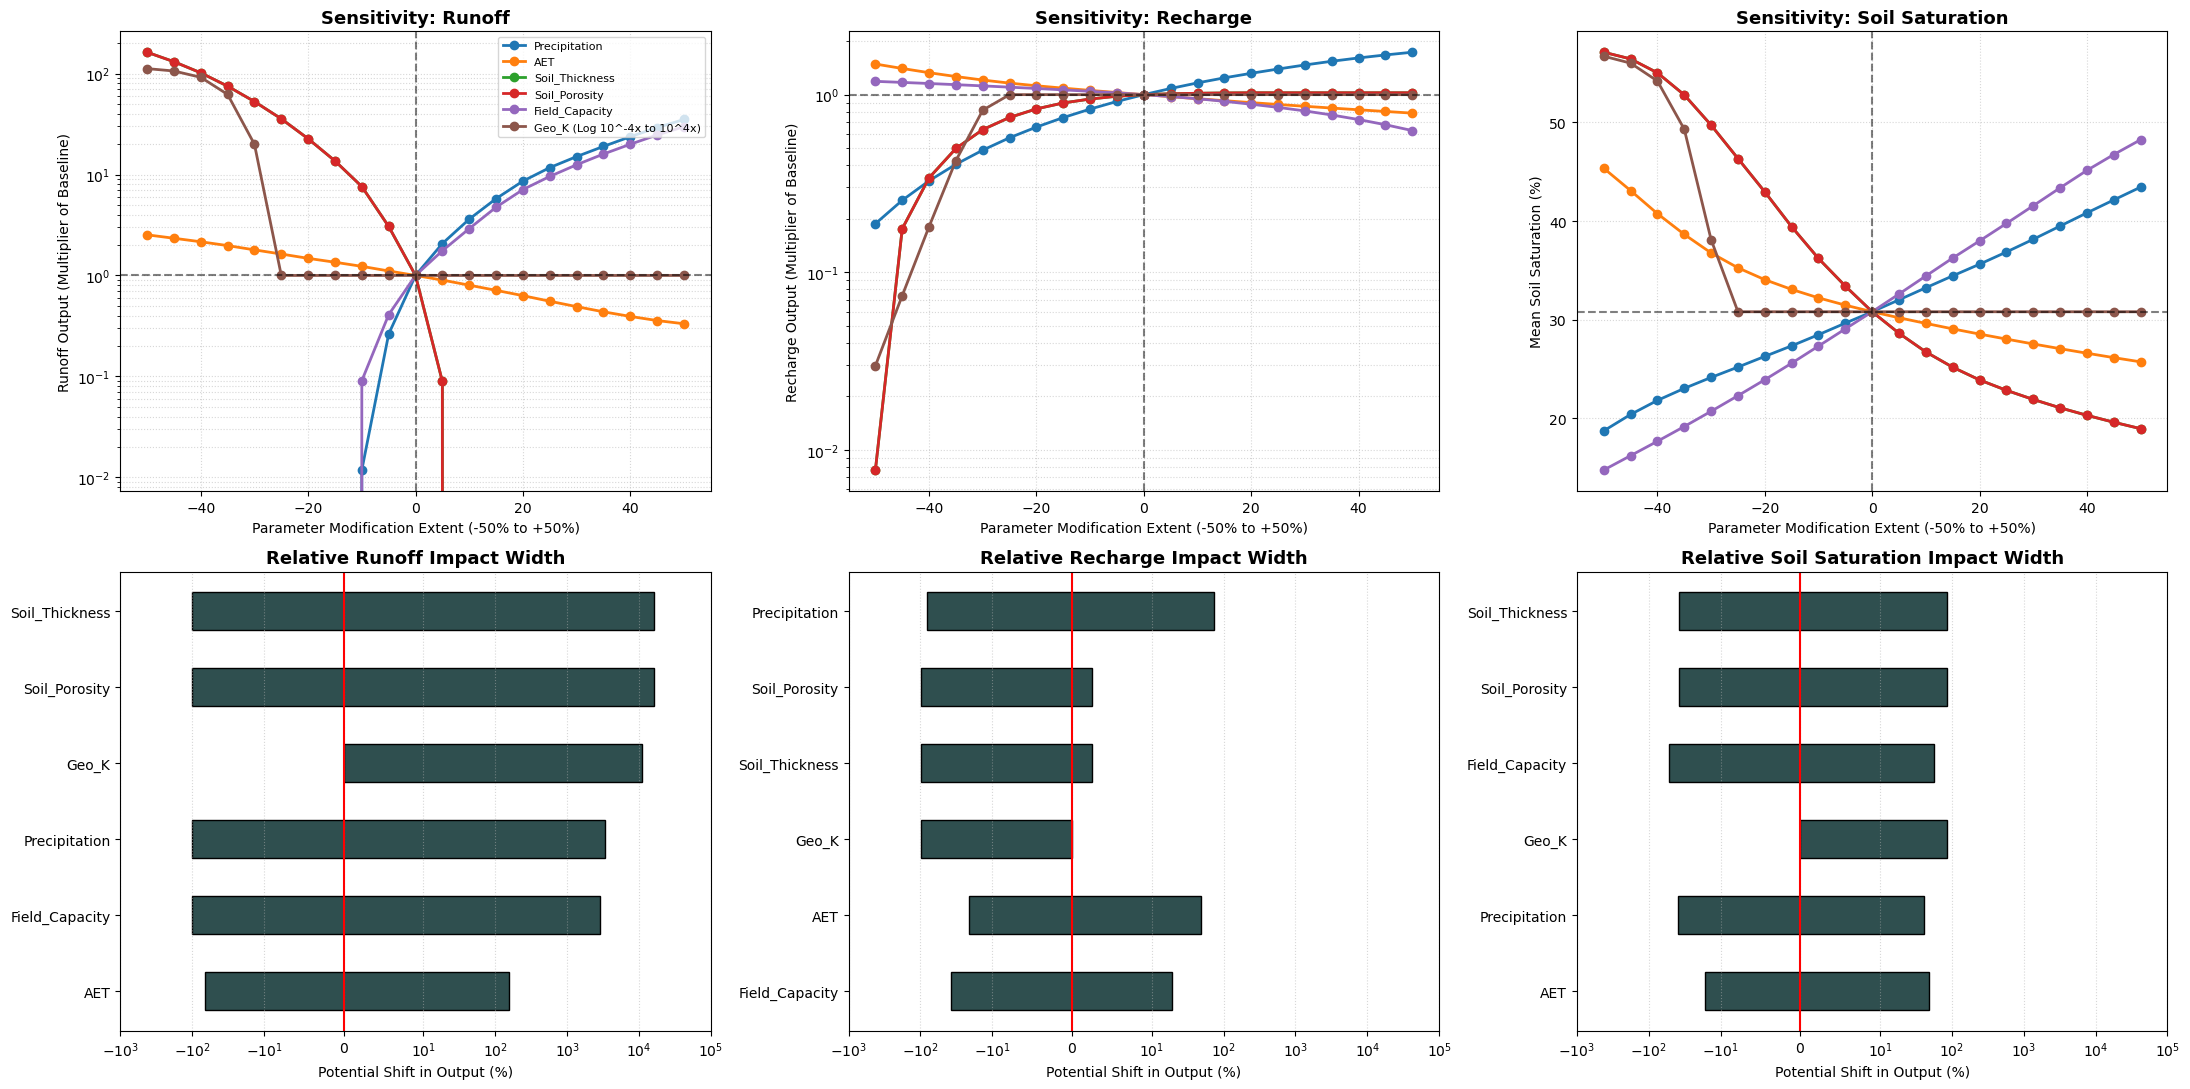

In [69]:
plot_fixed_visualizations(monte_carlo_run_df, save_file_path="C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Figures\\Climate_and_Validation_Figures\\UBM_Post_Calibration_Figures\\svgs\\ubm_sensitivity_analysis.svg")